## ADSR Envelope Modulation

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from engine import ADSREnvelope, SquareOscillator, getadsr

figsize = (25, 6.25)
colors = "#323031", "#308E91", "#34369D", "#5E2A7E", "#5E2A7E", "#6F3384"

# Set up plotting style
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["font.size"] = 10


def plot(
    xy,
    r=1,
    c=1,
    i=1,
    title="",
    xlabel="",
    ylabel="",
    yticks=None,
    xticks=None,
    **plot_kwargs,
):
    # plt.plot helper
    if r > 0:
        plt.subplot(r, c, i)
    plt.title(title)
    if len(xy) == 2:
        plt.plot(*xy, **plot_kwargs)
    else:
        plt.plot(xy, **plot_kwargs)

    if xticks is not None:
        plt.xticks(xticks)
    if yticks is not None:
        plt.yticks(yticks)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)

## Creating an ADSR Envelope

In [2]:
env = ADSREnvelope(sample_rate=44100)
print(env)

ADSREnvelope(attack=0.05, decay=0.2, sustain=0.7, release=0.3)


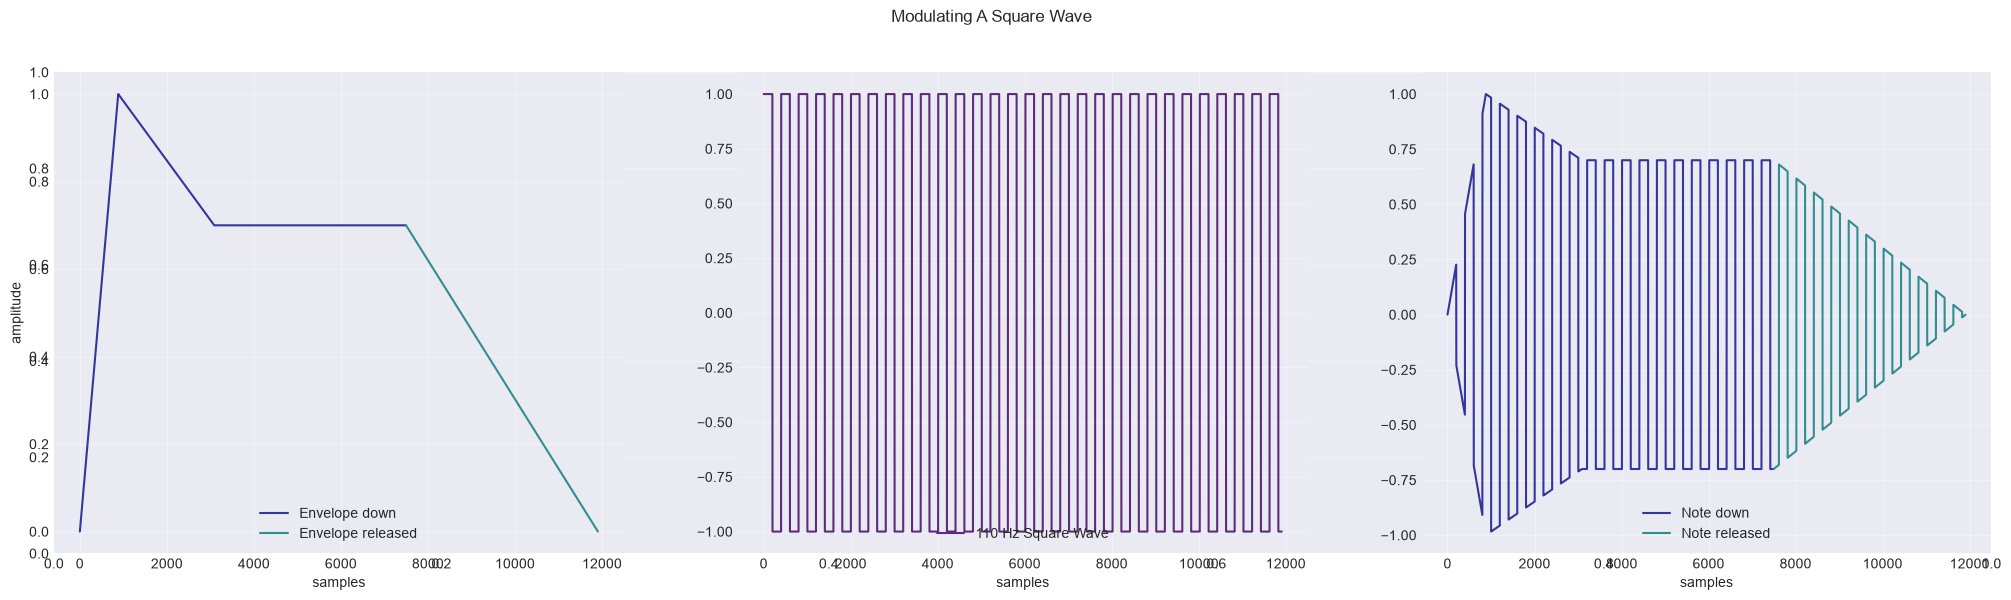

In [4]:
fig, _ = plt.subplots(figsize=figsize)
fig.suptitle("Modulating A Square Wave")
envvals, down, up = getadsr(0.02, 0.05, 0.7, 0.1, 0.1)
envvals = np.array(envvals)
xd = np.arange(down)
xu = np.arange(down, down + up)

plot((xd, envvals[:down]), 1, 3, 1, color=colors[2], label="Envelope down")
plot(
    (xu, envvals[down:]),
    0,
    3,
    1,
    color=colors[1],
    label="Envelope released",
    xlabel="samples",
    ylabel="amplitude",
)
plt.legend(loc="lower center")

osc = SquareOscillator(110)
env.trigger_note_on()
oscvals = osc.get_samples(reset=True)[: down + up]
plot(oscvals, 1, 3, 2, label="110 Hz Square Wave", xlabel="samples", color=colors[3])
plt.legend(loc="lower center")

plot((xd, oscvals[:down] * envvals[:down]), 1, 3, 3, color=colors[2], label="Note down")
plot(
    (xu, oscvals[down:] * envvals[down:]),
    0,
    3,
    3,
    color=colors[1],
    label="Note released",
    xlabel="samples",
)
plt.legend(loc="lower center")
plt.show()